In [29]:
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

import numpy as np
import matplotlib.dates as mdates
from statsmodels.tsa.stattools import grangercausalitytests
from statsmodels.tsa.stattools import adfuller
import statsmodels.api as sm
from statsmodels.tsa.api import VAR
from sklearn.metrics import mean_absolute_error, mean_squared_error
mpl.rcParams['figure.figsize'] = (10,8)
mpl.rcParams['axes.grid'] = False

In [30]:
df = pd.read_excel("df_practices.xlsx")

# Remove unwanted rows
# df = data.iloc[27:, :]

# Convert Date column to datetime
df['Date'] = pd.to_datetime(df['Date'])

# Sort values by date
df = df.sort_values('Date')


df.head()

,Date,Year,Season,Broadcasting,Transplant_Rows,Transplant_NotRows,Parachute,Machine,Other(sowing),Chemical_only,Organic_only,Both,None,Hand_Weeding,Weedicide,Water,No_Weeding
0,1992-04-01,1992,Yala,206289,4428,34183,0,0,52,231242,1832,5765,7743,65949,141344,5281,35317
1,1992-09-01,1993,Maha,386215,25582,801007,0,0,4407,457118,6535,10623,6378,125113,303198,12065,2955
2,1993-04-01,1993,Yala,231523,8556,35255,0,0,327,253777,1034,10739,8809,61162,173641,6267,34184
3,1993-09-01,1994,Maha,425262,17962,90020,0,0,1595,485308,4265,19323,22100,122602,337143,13815,60558
4,1994-04-01,1994,Yala,286303,4542,42157,0,0,372,305036,2826,12881,12631,86369,203695,9320,33990


In [31]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 67 entries, 0 to 66
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Date                67 non-null     datetime64[us]
 1   Year                67 non-null     int64         
 2   Season              67 non-null     str           
 3   Broadcasting        67 non-null     int64         
 4   Transplant_Rows     67 non-null     int64         
 5   Transplant_NotRows  67 non-null     int64         
 6   Parachute           67 non-null     int64         
 7   Machine             67 non-null     int64         
 8   Other(sowing)       67 non-null     int64         
 9   Chemical_only       67 non-null     int64         
 10  Organic_only        67 non-null     int64         
 11  Both                67 non-null     int64         
 12  None                67 non-null     int64         
 13  Hand_Weeding        67 non-null     int64         
 14  Weedici

In [32]:
df = df[['Date','Chemical_only', 'Organic_only', 'Both',
       'None']]
df.shape

(67, 5)

In [33]:
# Set Date as index
df.set_index('Date', inplace=True)
df.head()

,Chemical_only,Organic_only,Both,None
Date,,,,
1992-04-01,231242,1832,5765,7743
1992-09-01,457118,6535,10623,6378
1993-04-01,253777,1034,10739,8809
1993-09-01,485308,4265,19323,22100
1994-04-01,305036,2826,12881,12631


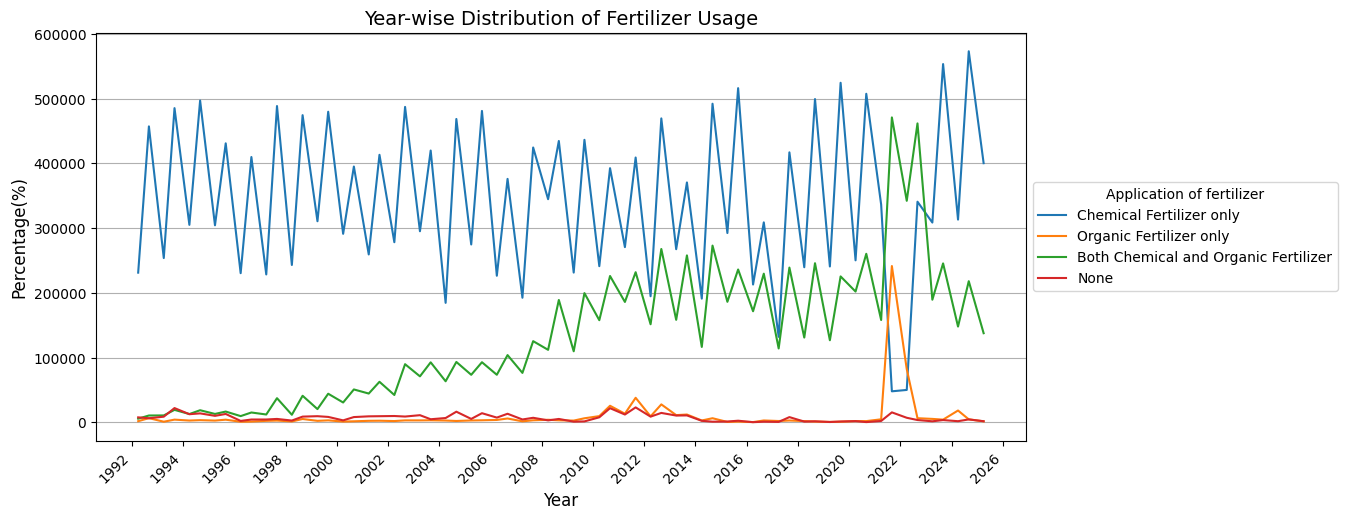

In [34]:
ax = df.plot(figsize=(12,6))

ax.xaxis.set_major_locator(mdates.YearLocator(2))       # tick every year
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))  # show only year
ax.set_ylim()
plt.xticks(rotation=45)
plt.xlabel("Year", fontsize=12)
plt.ylabel("Percentage(%)", fontsize=12)
plt.legend(["Chemical Fertilizer only","Organic Fertilizer only","Both Chemical and Organic Fertilizer","None"], title= "Application of fertilizer",loc="center left",
           bbox_to_anchor=(1, 0.5))
plt.title("Year-wise Distribution of Fertilizer Usage", fontsize=14)
plt.grid(axis='y')
plt.show()

In [35]:
# =========================================================
# ADF TEST FUNCTION
# =========================================================

def adf_check(series):

    result = adfuller(series.dropna())

    return result[0], result[1]


In [36]:
# =========================================================
# CHECK ORIGINAL STATIONARITY
# =========================================================

print("\nADF TEST RESULTS (ORIGINAL SERIES)")

diff_count = {}

for column in df.columns:

    adf_stat, p_value = adf_check(df[column])

    print(f"\n{column}")
    print(f"ADF Statistic : {adf_stat:.4f}")
    print(f"p-value       : {p_value:.4f}")

    d = 0
    temp_series = df[column].copy()

    while adf_check(temp_series)[1] > 0.05:

        temp_series = temp_series.diff().dropna()

        d += 1

        if d == 3:
            break

    diff_count[column] = d

    print(f"Differencing Needed : {d}")


ADF TEST RESULTS (ORIGINAL SERIES)

Chemical_only
ADF Statistic : -1.6155
p-value       : 0.4751
Differencing Needed : 1

Organic_only
ADF Statistic : -5.9700
p-value       : 0.0000
Differencing Needed : 0

Both
ADF Statistic : -0.3856
p-value       : 0.9125
Differencing Needed : 1

None
ADF Statistic : -2.8911
p-value       : 0.0464
Differencing Needed : 0


In [37]:

# =========================================================
# USE SAME DIFFERENCING ORDER FOR ALL SERIES
# =========================================================

max_diff = max(diff_count.values())

print("\nMaximum Differencing Order Used :", max_diff)

# =========================================================
# DIFFERENCE ALL SERIES EQUALLY
# =========================================================

df_diff = df.copy()

for i in range(max_diff):

    df_diff = df_diff.diff()

df_diff = df_diff.dropna()


Maximum Differencing Order Used : 1


In [38]:
df_diff.shape

(66, 4)

In [39]:
# =========================================================
# FINAL STATIONARITY TEST
# =========================================================

print("\nFINAL STATIONARITY RESULTS")

for column in df_diff.columns:

    adf_stat, p_value = adf_check(df_diff[column])

    print(f"\n{column}")
    print(f"ADF Statistic : {adf_stat:.4f}")
    print(f"p-value       : {p_value:.4f}")

    if p_value <= 0.05:
        print("Series is Stationary")

    else:
        print("Series is STILL NOT Stationary")


FINAL STATIONARITY RESULTS

Chemical_only
ADF Statistic : -5.2781
p-value       : 0.0000
Series is Stationary

Organic_only
ADF Statistic : -4.6432
p-value       : 0.0001
Series is Stationary

Both
ADF Statistic : -3.6568
p-value       : 0.0048
Series is Stationary

None
ADF Statistic : -14.1641
p-value       : 0.0000
Series is Stationary


In [40]:
# =========================================================
# TRAIN TEST SPLIT
# =========================================================

train_size = int(len(df_diff) * 0.8)

train = df_diff.iloc[:train_size]
test = df_diff.iloc[train_size:]

print("\nTrain Shape :", train.shape)
print("Test Shape  :", test.shape)


Train Shape : (52, 4)
Test Shape  : (14, 4)


In [41]:
# =========================================================
# FIT VAR MODEL
# =========================================================

model = VAR(train)

lag_selection = model.select_order(maxlags=8)

print("\nLAG SELECTION")
print(lag_selection.summary())

optimal_lag = lag_selection.aic

if optimal_lag is None:
    optimal_lag = 1

print("\nOptimal Lag :", optimal_lag)




LAG SELECTION
 VAR Order Selection (* highlights the minimums) 
      AIC         BIC         FPE         HQIC   
-------------------------------------------------
0       79.81       79.97   4.571e+34       79.87
1       76.05      76.87*   1.075e+33       76.35
2       76.08       77.54   1.129e+33       76.62
3       75.76       77.87   8.563e+32       76.54
4       75.80       78.56   9.873e+32       76.83
5       75.20       78.60   6.360e+32       76.46
6       75.25       79.31   8.873e+32       76.76
7       74.06       78.76  4.193e+32*       75.80
8      73.58*       78.93   5.361e+32      75.56*
-------------------------------------------------

Optimal Lag : 8


C:\Users\User\AppData\Roaming\Python\Python314\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


In [42]:
# fit VAR
var_model = model.fit(optimal_lag)

print(var_model.summary())

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Wed, 03, Jun, 2026
Time:                     01:42:30
--------------------------------------------------------------------
No. of Equations:         4.00000    BIC:                    78.9307
Nobs:                     44.0000    HQIC:                   75.5631
Log likelihood:          -1736.45    FPE:                5.36054e+32
AIC:                      73.5781    Det(Omega_mle):     5.71553e+31
--------------------------------------------------------------------
Results for equation Chemical_only
                      coefficient       std. error           t-stat            prob
-----------------------------------------------------------------------------------
const                 3702.243835     29244.148935            0.127           0.899
L1.Chemical_only        -0.744167         0.400745           -1.857           0.063
L1.Organic_only         -6.179063       

In [43]:
# =========================================================
# FORECASTING
# =========================================================

forecast_input = train.values[-optimal_lag:]

forecast = var_model.forecast(
    y=forecast_input,
    steps=len(test)
)

forecast_diff = pd.DataFrame(
    forecast,
    index=test.index,
    columns=test.columns
)

print("\nForecast Values (Differenced Scale)")
print(forecast_diff.head())


Forecast Values (Differenced Scale)
            Chemical_only  Organic_only          Both          None
Date                                                               
2018-09-01  -16797.065763 -12797.544946   5816.477202 -16401.526431
2019-04-01   92344.413545  -7819.167481  -7719.834598  -4023.965122
2019-09-01  -39617.487785   8115.270904  47490.500581   7768.094573
2020-04-01  -32502.473607 -26695.312621 -90870.926013 -10449.426614
2020-09-01   69290.463425  14550.382732  54848.754391  -6147.791402


In [44]:
# =========================================================
# INVERSE DIFFERENCING
# =========================================================

forecast_lvl1 = forecast_diff.cumsum() + train.diff().iloc[-1]

forecast_original = (
    forecast_lvl1.cumsum()
    + df.iloc[train_size + max_diff - 1]
)

print("\nForecast Values (Original Scale)")
print(forecast_original.head())


Forecast Values (Original Scale)
            Chemical_only   Organic_only          Both           None
Date                                                                 
2018-09-01  -2.395911e+05  -12511.544946 -9.630052e+04  -29509.526431
2019-04-01  -6.264147e+05  -34857.257372 -3.312719e+05  -64263.017984
2019-09-01  -1.052856e+06  -49087.698894 -5.187527e+05  -91248.414965
2020-04-01  -1.511799e+06  -90013.453037 -7.971045e+05 -128683.238559
2020-09-01  -1.901453e+06 -116388.824449 -1.020608e+06 -172265.853556


In [45]:
# =========================================================
# ACTUAL VALUES
# =========================================================

actual = df.iloc[train_size + max_diff:]

# align indexes
forecast_original = forecast_original.loc[actual.index]


In [46]:
forecast_original

,Chemical_only,Organic_only,Both,None
Date,,,,
2018-09-01,-2.395911e+05,-12511.544946,-9.630052e+04,-29509.526431
2019-04-01,-6.264147e+05,-34857.257372,-3.312719e+05,-64263.017984
2019-09-01,-1.052856e+06,-49087.698894,-5.187527e+05,-91248.414965
2020-04-01,-1.511799e+06,-90013.453037,-7.971045e+05,-128683.238559
2020-09-01,-1.901453e+06,-116388.824449,-1.020608e+06,-172265.853556
2021-04-01,-2.297540e+06,-149295.468659,-1.275589e+06,-204072.826158
2021-09-01,-2.761751e+06,-176216.401275,-1.467892e+06,-243375.541739
2022-04-01,-3.115801e+06,-207239.098582,-1.735692e+06,-277793.747255
2022-09-01,-3.573500e+06,-225862.951400,-1.922215e+06,-309556.427351


In [47]:
# =========================================================
# MODEL EVALUATION
# =========================================================

print("\nMODEL EVALUATION")

for column in df.columns:

    mae = mean_absolute_error(
        actual[column],
        forecast_original[column]
    )

    rmse = np.sqrt(
        mean_squared_error(
            actual[column],
            forecast_original[column]
        )
    )

    mape = np.mean(
        np.abs(
            (actual[column] - forecast_original[column])
            / (actual[column] + 1e-10)
        )
    ) * 100

    print(f"\n{column}")
    print(f"MAE  : {mae:.4f}")
    print(f"RMSE : {rmse:.4f}")
    print(f"MAPE : {mape:.2f}%")


MODEL EVALUATION

Chemical_only
MAE  : 3378521.1542
RMSE : 3832281.9960
MAPE : 1630.45%

Organic_only
MAE  : 209318.7478
RMSE : 244065.1485
MAPE : 5077.35%

Both
MAE  : 1839921.4067
RMSE : 2062241.1875
MAPE : 872.65%

None
MAE  : 259261.0098
RMSE : 295414.9232
MAPE : 12757.89%


In [48]:
# =========================================================
# STABILITY CHECK
# =========================================================

print("\nIs VAR Model Stable?")
print(var_model.is_stable())


Is VAR Model Stable?
False


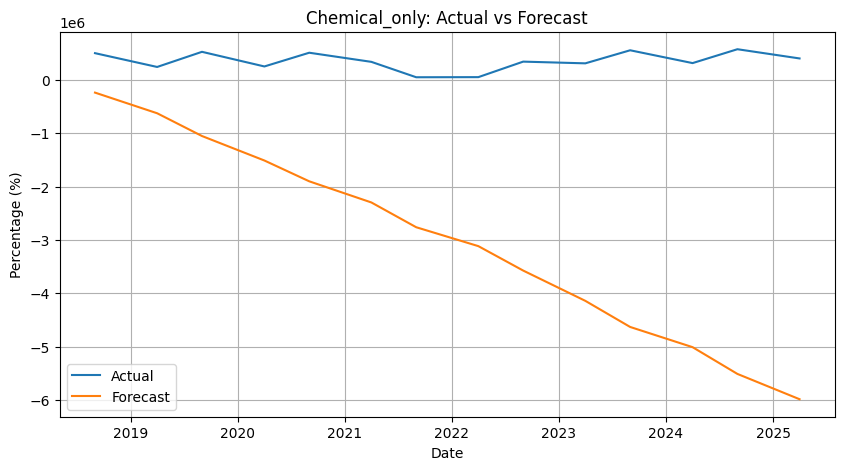

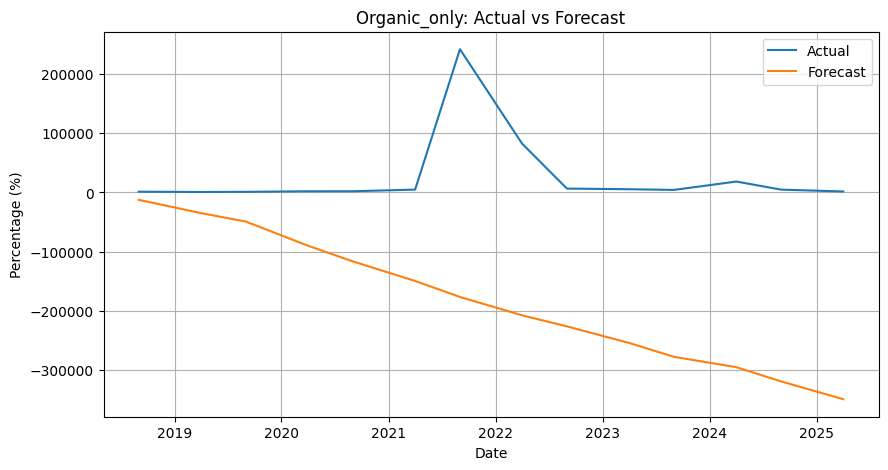

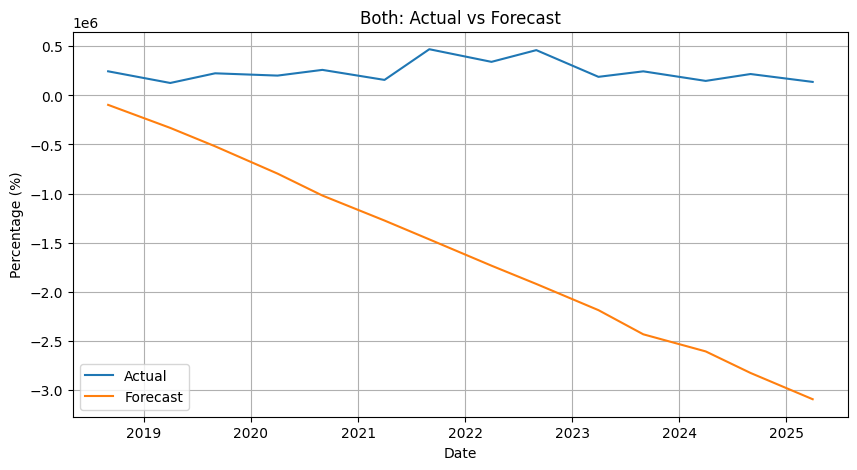

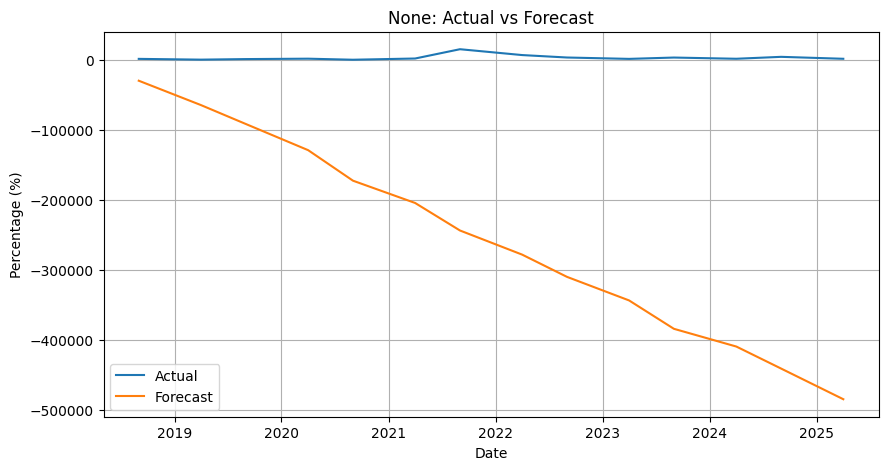

In [49]:
# =========================================================
# ACTUAL VS FORECAST PLOTS
# =========================================================

for column in df.columns:

    plt.figure(figsize=(10,5))

    plt.plot(
        actual.index,
        actual[column],
        label='Actual'
    )

    plt.plot(
        forecast_original.index,
        forecast_original[column],
        label='Forecast'
    )

    plt.title(f'{column}: Actual vs Forecast')

    plt.xlabel("Date")
    plt.ylabel("Percentage (%)")

    plt.legend()

    plt.grid(True)

    plt.show()